# Plots for SPH Code
This notebook requires the python file "Plotting_Code.py" to run. Ensure it is in the same file when running this notebook.

To generate new results, run the associated C++ file first, with new parameters specified in the "INPUTS.txt" file. Then re-run this notebook.

There is also another python file called "SPH_animations.py". This also requires "Plotting_Code.py" to be in the same file to run, but the animations file is intended to run on its own.

In [1]:
# Imports
from Plotting_Code import *

In [2]:
# Read data file
pos, vel, rho, P, E, E_err, tot_mom, time = read_data("DATA.txt")
# Initialise values for analytical solution
rho1 = rho[0][0]
rho2 = rho[0][-1]
P1 = P[0][0]
P2 = P[0][-1]
gamma = 1.4
xs = np.linspace(-0.5,0.5,100)
GAMMA = (gamma-1)/(gamma+1)
BETA = (gamma-1)/(2*gamma)

250


# Analytical Solution

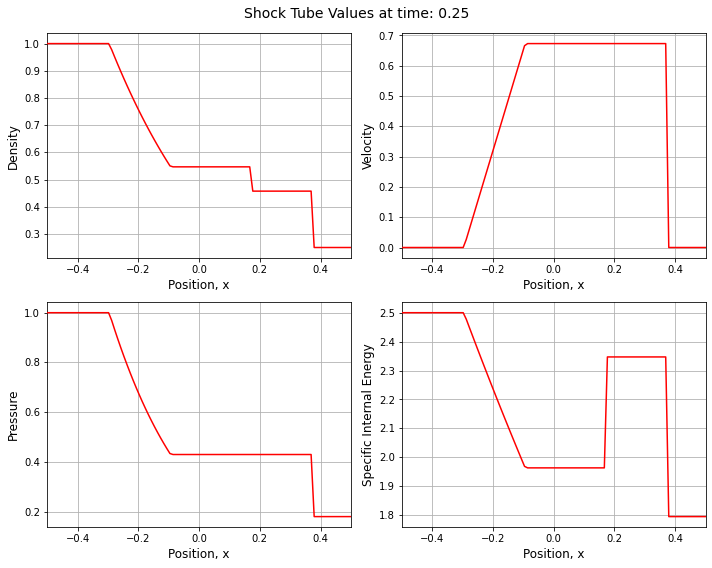

In [3]:
# Find final timestep time
t = 0.25
# Find analytical solutions
d, p, v, u = analytical_shocktube(1.0, 0.25, 1.0, 0.1795, 1.4, xs, t)

# Make and label axes
fig, axs = plt.subplots(2,2, figsize=(10,8))
fig.suptitle(f"Shock Tube Values at time: {t}", fontsize=14)
axs[0,0].set_xlabel("Position, x", fontsize=12), axs[0,0].set_ylabel("Density", fontsize=12), axs[0,0].grid(visible=True)
axs[0,1].set_xlabel("Position, x", fontsize=12), axs[0,1].set_ylabel("Velocity", fontsize=12), axs[0,1].grid(visible=True)
axs[1,0].set_xlabel("Position, x", fontsize=12), axs[1,0].set_ylabel("Pressure", fontsize=12), axs[1,0].grid(visible=True)
axs[1,1].set_xlabel("Position, x", fontsize=12), axs[1,1].set_ylabel("Specific Internal Energy", fontsize=12), axs[1,1].grid(visible=True)
axs[0,0].set_xlim(-0.5,0.5), axs[0,1].set_xlim(-0.5,0.5), axs[1,0].set_xlim(-0.5,0.5), axs[1,1].set_xlim(-0.5,0.5)

# Plot analytical solutions
axs[0,0].plot(xs, d, c='r', zorder=3, label="Analytical")
axs[0,1].plot(xs, v, c='r', zorder=3, label="Analytical")
axs[1,0].plot(xs, p, c='r', zorder=3, label="Analytical")
axs[1,1].plot(xs, u, c='r', zorder=3, label="Analytical")

plt.tight_layout()

fig.savefig("Analytical_Solution.png", dpi=300)

# SPH Simulated Solution

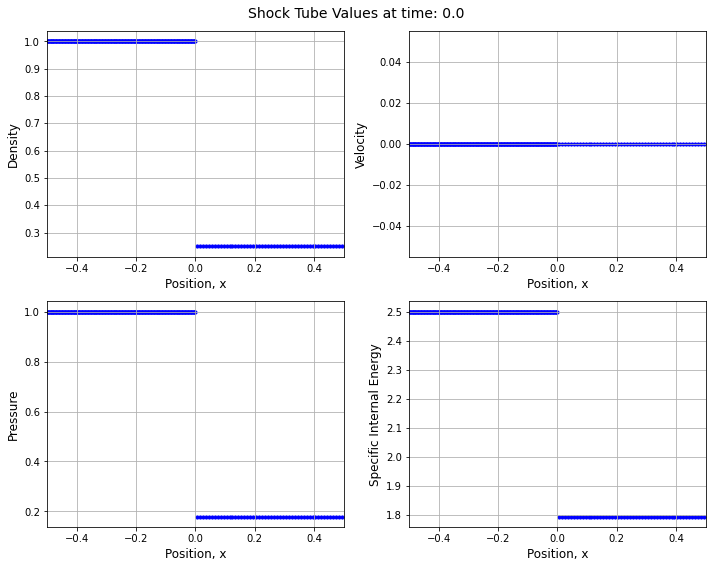

In [4]:
# Plot initial conditions
fig, axs = plt.subplots(2,2, figsize=(10,8))
fig.suptitle(f"Shock Tube Values at time: {time[0]}", fontsize=14)
axs[0,0].set_xlabel("Position, x", fontsize=12), axs[0,0].set_ylabel("Density", fontsize=12), axs[0,0].grid(visible=True)
axs[0,1].set_xlabel("Position, x", fontsize=12), axs[0,1].set_ylabel("Velocity", fontsize=12), axs[0,1].grid(visible=True)
axs[1,0].set_xlabel("Position, x", fontsize=12), axs[1,0].set_ylabel("Pressure", fontsize=12), axs[1,0].grid(visible=True)
axs[1,1].set_xlabel("Position, x", fontsize=12), axs[1,1].set_ylabel("Specific Internal Energy", fontsize=12), axs[1,1].grid(visible=True)
axs[0,0].set_xlim(-0.5,0.5), axs[0,1].set_xlim(-0.5,0.5), axs[1,0].set_xlim(-0.5,0.5), axs[1,1].set_xlim(-0.5,0.5)

axs[0,0].scatter(pos[0], rho[0], c='b', s=10)
axs[0,1].scatter(pos[0], vel[0], c='b', s=10)
axs[1,0].scatter(pos[0], P[0], c='b', s=10)
axs[1,1].scatter(pos[0], E[0], c='b', s=10)

plt.tight_layout()

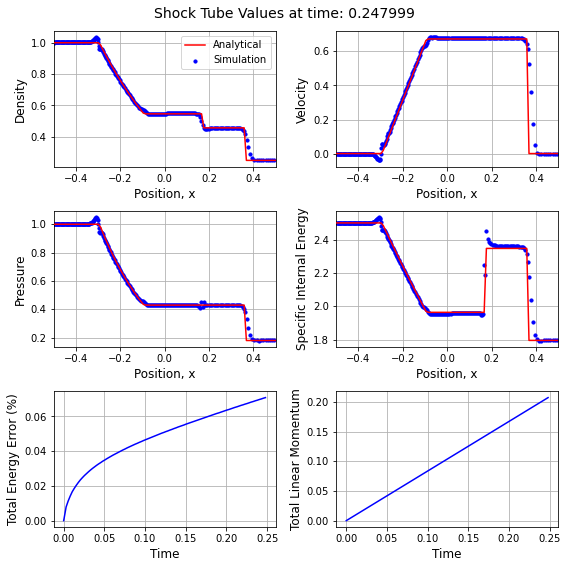

In [5]:
# Plot final conditions
# Find final timestep time
t = time[-1]
# Find analytical solutions
d, p, v, u = analytical_shocktube(rho1, rho2, P1, P2, gamma, xs, t)

# Make and label axes
fig, axs = plt.subplots(3,2, figsize=(8,8))
fig.suptitle(f"Shock Tube Values at time: {time[-1]}", fontsize=14)
axs[0,0].set_xlabel("Position, x", fontsize=12), axs[0,0].set_ylabel("Density", fontsize=12), axs[0,0].grid(visible=True)
axs[0,1].set_xlabel("Position, x", fontsize=12), axs[0,1].set_ylabel("Velocity", fontsize=12), axs[0,1].grid(visible=True)
axs[1,0].set_xlabel("Position, x", fontsize=12), axs[1,0].set_ylabel("Pressure", fontsize=12), axs[1,0].grid(visible=True)
axs[1,1].set_xlabel("Position, x", fontsize=12), axs[1,1].set_ylabel("Specific Internal Energy", fontsize=12), axs[1,1].grid(visible=True)
axs[2,0].set_xlabel("Time", fontsize=12), axs[2,0].set_ylabel("Total Energy Error (%)", fontsize=12), axs[2,0].grid(visible=True)
axs[2,1].set_xlabel("Time", fontsize=12), axs[2,1].set_ylabel("Total Linear Momentum", fontsize=12), axs[2,1].grid(visible=True)
axs[0,0].set_xlim(-0.5,0.5), axs[0,1].set_xlim(-0.5,0.5), axs[1,0].set_xlim(-0.5,0.5), axs[1,1].set_xlim(-0.5,0.5)

# Plot analytical and simulated results
# Analytical
axs[0,0].plot(xs, d, c='r', zorder=3, label="Analytical")
axs[0,1].plot(xs, v, c='r', zorder=3, label="Analytical")
axs[1,0].plot(xs, p, c='r', zorder=3, label="Analytical")
axs[1,1].plot(xs, u, c='r', zorder=3, label="Analytical")
# Simulated
axs[0,0].scatter(pos[-1], rho[-1], c='b', s=10, zorder=2, label="Simulation")
axs[0,1].scatter(pos[-1], vel[-1], c='b', s=10, zorder=2, label="Simulation")
axs[1,0].scatter(pos[-1], P[-1], c='b', s=10, zorder=2, label="Simulation")
axs[1,1].scatter(pos[-1], E[-1], c='b', s=10, zorder=2, label="Simulation")
axs[2,0].plot(time, E_err, c='b', zorder=2, label="Simulation")
axs[2,1].plot(time, tot_mom, c='b', zorder=2, label="Simulation")

axs[0,0].legend()
plt.tight_layout()